# Analyzing the weekday increment operator on a templated dataset

In [1]:
# Notebook setup
%cd /home/can/feature_zoo/
%load_ext autoreload
%autoreload 2

/home/can/feature_zoo


In [2]:
# Initialize Experiment config (defines dataset, model, sae)


from src.config import load_config

overrides_list = [
    "llm=gpt2",
    # "llm=llama3.1-8b-base", # Uncomment to switch models or select multiple models.
    # "llm=olmo3-32b-base",
]

In [3]:
from src.cache_llm import load_short_trajectory_acts
import torch as th
import numpy as np
import matplotlib.pyplot as plt
import einops
import time

def to_numpy(t: th.Tensor) -> np.ndarray:
    return t.detach().cpu().float().numpy()

# Cache data for all models
model_data = {}  # {model_name: {"labels", "texts", "input_ids_BT", "llm_BWD"}}

for override in overrides_list:
    # Clear CUDA cache before loading new model
    th.cuda.empty_cache()
    
    cfg = load_config(overrides=[override])
    model_name = cfg.llm.name
    print(f"Loading {model_name}...")
    return_dict = load_short_trajectory_acts(cfg, force_recompute=True) # For now, leave force_recompute=True, I get buggy results for force recompute=False

    # Move to CPU immediately to free GPU memory
    if isinstance(return_dict["llm_BWD"], th.Tensor):
        llm_BWD = to_numpy(return_dict["llm_BWD"])
        input_ids_BT = return_dict["input_ids_BT"].cpu() if isinstance(return_dict["input_ids_BT"], th.Tensor) else return_dict["input_ids_BT"]
    
    model_data[model_name] = {
        "labels": return_dict["labels"],
        "texts": return_dict["texts"],
        "input_ids_BT": input_ids_BT,
        "llm_BWD": llm_BWD,
    }
    
    del return_dict
    
    print(f"  {model_name} llm_BWD shape: {llm_BWD.shape}")
    

/home/can/feature_zoo/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading gpt2...


LLM Cache: 100%|██████████| 9/9 [00:00<00:00, 30.77it/s]


  gpt2 llm_BWD shape: (123, 7, 768)


The dataset contains short webtext sentence templates that end with a weekday.
Example: The local mayor said an important statement last [WEEKDAY]

We extract representations at the final token of the [WEEKDAY]. Every template occurs 7 times in the dataset, once for each weekday.
Importantly, we minimize the template-related information by subtracting the mean per template.

In [4]:
for model_name in model_data:
    llm_BWD = model_data[model_name]["llm_BWD"]
    model_data[model_name]["llm_BWD"] = llm_BWD - np.mean(llm_BWD, axis=1, keepdims=True)

# SVD

In [5]:
# Compute SVD for each model
model_svd = {}  # {model_name: {"U_BWD", "S", "Vh", "rel_energy", "cumsum_rel_energy"}}

for model_name, data in model_data.items():
    llm_BWD = data["llm_BWD"]
    llm_BD = einops.rearrange(llm_BWD, "B W D -> (B W) D")
    U, S, Vh = np.linalg.svd(llm_BD, full_matrices=False)
    U_BWD = einops.rearrange(U, "(B W) D -> B W D", W=7)

    rel_energy = S**2 / (S**2).sum()
    cumsum_rel_energy = np.cumsum(rel_energy)

    model_svd[model_name] = {
        "U_BWD": U_BWD,
        "S": S,
        "Vh": Vh,
        "rel_energy": rel_energy,
        "cumsum_rel_energy": cumsum_rel_energy,
    }
    print(f"{model_name}: top-6 cumsum energy = {cumsum_rel_energy[5]:.3f}")

gpt2: top-6 cumsum energy = 0.905


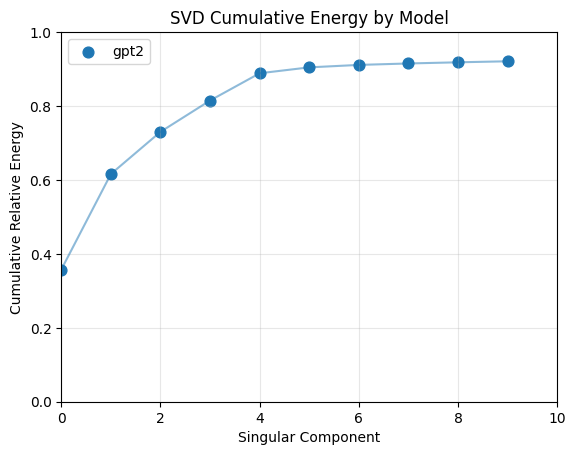

In [6]:
def plot_SVD_energy_multi(model_svd: dict):
    """Plot cumulative energy for all models on same axes."""
    colors = plt.cm.tab10(np.linspace(0, 1, len(model_svd)))

    for idx, (model_name, svd_data) in enumerate(model_svd.items()):
        cumsum = svd_data["cumsum_rel_energy"][:10]
        indices = np.arange(len(cumsum))
        plt.scatter(indices, cumsum,
                   c=[colors[idx]], marker='o',
                   label=model_name, s=60)
        plt.plot(indices, cumsum, c=colors[idx], alpha=0.5)

    plt.xlim(0, 10)
    plt.ylim(0, 1)
    plt.xlabel('Singular Component')
    plt.ylabel('Cumulative Relative Energy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.title('SVD Cumulative Energy by Model')
    plt.show()

plot_SVD_energy_multi(model_svd)

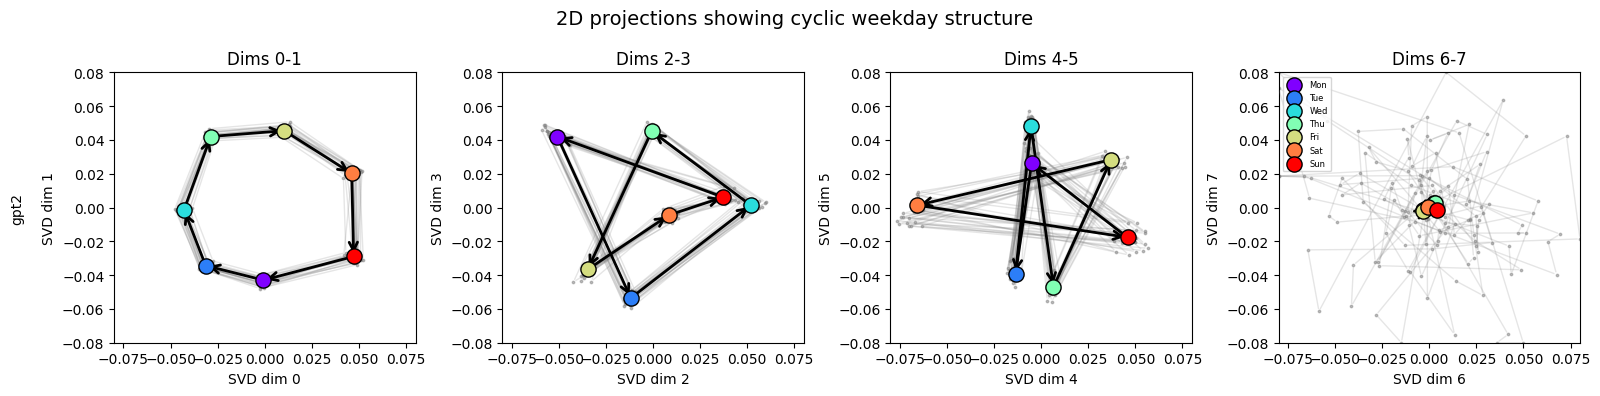

In [7]:
from typing import Callable

def plot_2d_projections_multi(
    model_data: dict,
    n_cols: int,
    get_projection: Callable[[dict, int], tuple[np.ndarray, np.ndarray, str, str, str]],
    suptitle: str,
    axlim: float | None = None,
    equal_aspect: bool = False,
    hide_ticks: bool = False,
):
    """
    Plot 2D projections of weekday trajectories for multiple models.

    Args:
        model_data: dict mapping model_name -> data dict (structure depends on get_projection)
        n_cols: number of subplot columns
        get_projection: callable(data_dict, col_idx) -> (proj_x_BW, proj_y_BW, xlabel, ylabel, title)
        suptitle: title for the entire figure
        axlim: fixed axis limit. If None, computed dynamically per subplot.
        equal_aspect: whether to set equal aspect ratio on subplots
        hide_ticks: whether to hide all axis ticks, tick labels, subplot titles, and figure title
    """
    n_models = len(model_data)
    fig, axes = plt.subplots(n_models, n_cols, figsize=(4 * n_cols, 4 * n_models))

    if n_models == 1:
        axes = axes.reshape(1, -1)

    weekday_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    colors = plt.cm.rainbow(np.linspace(0, 1, 7))

    for row, (model_name, data) in enumerate(model_data.items()):
        for col in range(n_cols):
            ax = axes[row, col]
            
            proj_x_BW, proj_y_BW, xlabel, ylabel, title = get_projection(data, col)

            # Determine axis limits
            if axlim is not None:
                current_axlim = axlim
            else:
                current_axlim = np.max(np.abs([proj_x_BW, proj_y_BW])) * 1.1

            # Plot individual trajectories (gray)
            for b in range(min(20, proj_x_BW.shape[0])):
                x_coords = np.clip(proj_x_BW[b], -current_axlim, current_axlim)
                y_coords = np.clip(proj_y_BW[b], -current_axlim, current_axlim)
                for w in range(7):
                    next_w = (w + 1) % 7
                    ax.annotate('', xy=(x_coords[next_w], y_coords[next_w]),
                            xytext=(x_coords[w], y_coords[w]),
                            arrowprops=dict(arrowstyle='-', alpha=0.2, color='gray'),
                            annotation_clip=True)
                    ax.scatter(x_coords[w], y_coords[w], c='grey', s=3, alpha=0.5)

            # Plot mean trajectory (colored)
            mean_x = proj_x_BW.mean(axis=0)
            mean_y = proj_y_BW.mean(axis=0)
            for w in range(7):
                ax.scatter(mean_x[w], mean_y[w], c=[colors[w]], s=120,
                        label=weekday_labels[w] if col == n_cols - 1 else None,
                        zorder=5, edgecolors='black')
                next_w = (w + 1) % 7
                ax.annotate('', xy=(mean_x[next_w], mean_y[next_w]),
                        xytext=(mean_x[w], mean_y[w]),
                        arrowprops=dict(arrowstyle='->', color='black', lw=2, mutation_scale=15),
                        annotation_clip=True)

            ax.set_xlim((-current_axlim, current_axlim))
            ax.set_ylim((-current_axlim, current_axlim))
            
            if hide_ticks:
                ax.set_xticks([])
                ax.set_yticks([])
            else:
                ax.set_xlabel(xlabel)
                if col == 0:
                    ax.set_ylabel(f'{model_name}\n\n{ylabel}')
                else:
                    ax.set_ylabel(ylabel)
                if row == 0:
                    ax.set_title(title)

            if col == n_cols - 1:
                ax.legend(loc='upper left', fontsize=6)
            if equal_aspect:
                ax.set_aspect('equal')

    if not hide_ticks:
        plt.suptitle(suptitle, fontsize=14)
    plt.tight_layout()
    plt.show()


# Plot SVD eigendata
def svd_projection(data: dict, col: int):
    """Get SVD dimension pair projection."""
    dim_pairs = [(0, 1), (2, 3), (4, 5), (6, 7)]
    dim1, dim2 = dim_pairs[col]
    U_BWD = data["U_BWD"]
    return (
        U_BWD[:, :, dim1],
        U_BWD[:, :, dim2],
        f'SVD dim {dim1}',
        f'SVD dim {dim2}',
        f'Dims {dim1}-{dim2}'
    )

plot_2d_projections_multi(
    model_svd, n_cols=4, get_projection=svd_projection,
    suptitle="2D projections showing cyclic weekday structure", axlim=0.08
)

# Day Increment Operator / Transition Matrix

In [8]:
# Compute Increment operator for each model
model_increment = {}  # {model_name: {"A_CC", "eval_E", "evec_EC", "U_BWC", "planesX_EC", "planesY_EC", "positive_eval_idx_E"}}

for model_name, svd_data in model_svd.items():
    U_BWD = svd_data["U_BWD"]
    U_BWC = U_BWD[:, :, :6]
    
    batch_arange = np.arange(U_BWC.shape[0])
    weekday_arange = np.arange(U_BWC.shape[1])
    weekday_increment = np.concatenate([weekday_arange[1:], [0]])
    
    X_next_BWC = U_BWC[batch_arange[:, None], weekday_increment[None, :]]
    
    X_current_BC = einops.rearrange(U_BWC, "B W C -> (B W) C")
    X_next_BC = einops.rearrange(X_next_BWC, "B W C -> (B W) C")
    U_inv_DB = einops.rearrange(U_BWD, "B W D -> D (B W)")
    X_inv_current_CB = U_inv_DB[:6]
    
    # A_CC @ X_current_BC.T = X_next_BC.T
    A_CC = X_next_BC.T @ X_inv_current_CB.T
    eval_E, evec_CE = np.linalg.eig(A_CC)
    evec_EC = evec_CE.T
    
    # Get indices for positive imaginary eigenvalues (conjugate pairs)
    positive_eval_idx_E = [i for i in range(len(eval_E)) if np.imag(eval_E[i]) > 0]
    planesX_EC = np.real(evec_EC[positive_eval_idx_E])
    planesY_EC = np.imag(evec_EC[positive_eval_idx_E])
    
    model_increment[model_name] = {
        "A_CC": A_CC,
        "eval_E": eval_E,
        "evec_EC": evec_EC,
        "U_BWC": U_BWC,
        "planesX_EC": planesX_EC,
        "planesY_EC": planesY_EC,
        "positive_eval_idx_E": positive_eval_idx_E,
    }
    
    print(f"{model_name}: eigenvalues = {eval_E}")

gpt2: eigenvalues = [ 0.6228997 +0.7808953j   0.6228997 -0.7808953j  -0.22114184+0.9718982j
 -0.22114184-0.9718982j  -0.88350064+0.42726097j -0.88350064-0.42726097j]


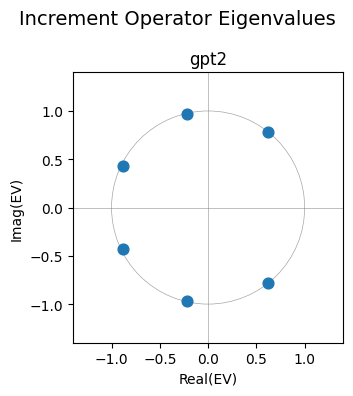

In [9]:
def plot_complex_ev_multi(model_increment: dict, axlim=1.4) -> None:
    """Plot eigenvalues for all models."""
    n_models = len(model_increment)
    fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4))
    
    if n_models == 1:
        axes = [axes]
    
    for idx, (model_name, inc_data) in enumerate(model_increment.items()):
        ax = axes[idx]
        evals = inc_data["eval_E"]
        
        ax.axhline(0, color='gray', linewidth=0.5, alpha=0.7)
        ax.axvline(0, color='gray', linewidth=0.5, alpha=0.7)
        circle = plt.Circle((0, 0), 1, color='gray', fill=False, linewidth=0.5, alpha=0.7)
        ax.add_patch(circle)
        
        ax.scatter(np.real(evals), np.imag(evals), s=60)
        
        ax.set_xlim(-axlim, axlim)
        ax.set_ylim(-axlim, axlim)
        ax.set_xlabel("Real(EV)")
        ax.set_ylabel("Imag(EV)")
        ax.set_title(model_name)
        ax.set_aspect('equal')
    
    plt.suptitle('Increment Operator Eigenvalues', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_complex_ev_multi(model_increment)

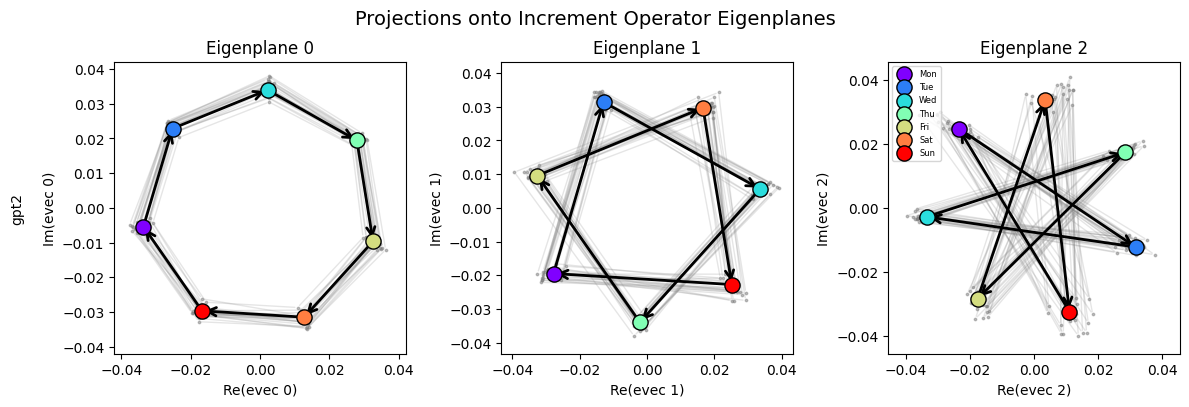

In [10]:
# Plot eigenplane projections using the generalized function
def eigenplane_projection(data: dict, col: int):
    """Get eigenplane projection."""
    U_BWC = data["U_BWC"]
    planesX_EC = data["planesX_EC"]
    planesY_EC = data["planesY_EC"]
    return (
        U_BWC @ planesX_EC[col],
        U_BWC @ planesY_EC[col],
        f'Re(evec {col})',
        f'Im(evec {col})',
        f'Eigenplane {col}'
    )

plot_2d_projections_multi(
    model_increment, n_cols=3, get_projection=eigenplane_projection,
    suptitle="Projections onto Increment Operator Eigenplanes", equal_aspect=True, hide_ticks=False
)

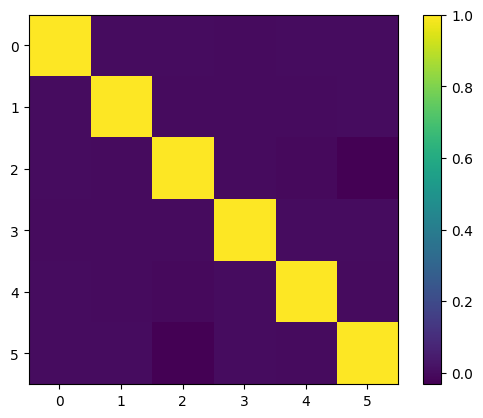

In [11]:
# Eigenvectors are not necessarily orthogonal. The images look very different, so this strongly suggests they are. Nevertheless, let's doublecheck they are orthogonal.
# The right singular vectors of the representation data llm_BD = U S Vh map.

Vh = model_svd["gpt2"]["Vh"]
planes_2EC = np.concat((model_increment["gpt2"]["planesX_EC"], model_increment["gpt2"]["planesY_EC"]), axis=0)
planes_2ED = planes_2EC @ Vh[:6, :]
planes_2ED = planes_2ED / np.linalg.norm(planes_2ED, axis=-1, keepdims=True)

plt.imshow(planes_2ED @ planes_2ED.T)
plt.colorbar()

Next, it would be interesting to find which weights in GPT-2 implement the weekday-increment operator.